In [28]:
import pandas as pd
from matplotlib import pyplot as plt

In [29]:
file = r"C:\Users\Win\Downloads\hyrox_result.csv"
df = pd.read_csv(file)
df

,race_name,race_country,race_category,age_category,overall_rank,ag_rank,finish_time,nationality
0,Beijing 2026,China,Open Men,35-39,1,1,0:57:41,CHN
1,Beijing 2026,China,Open Men,30-34,2,1,0:57:45,GER
2,Beijing 2026,China,Open Men,30-34,3,2,0:58:26,CHN
3,Beijing 2026,China,Open Men,30-34,4,3,0:58:50,NZL
4,Beijing 2026,China,Open Men,40-44,5,1,0:59:02,CHN
...,...,...,...,...,...,...,...,...
2630,Chiba 2026,Japan,Pro Doubles Women,25-29,73,20,2:00:38,TPE/JPN
2631,Chiba 2026,Japan,Pro Doubles Women,25-29,74,21,2:02:12,JPN
2632,Chiba 2026,Japan,Pro Doubles Women,25-29,75,22,2:07:40,USA/PHI
2633,Chiba 2026,Japan,Pro Doubles Women,16-24,76,7,2:10:50,JPN


## EP 1: Domination of home athletes and top 100 finish time pattern

In [30]:
def home_athlete_prop(df, country, category, nationality):
    category_df = df[(df['race_category'] == category) & (df['race_country'] == country)]
    return round((category_df['nationality'] == nationality).mean(), 2)

# city label -> (race_country value in df, home nationality code)
home_map = {
    'Beijing': ('China', 'CHN'),
    'Bangkok': ('Thailand', 'THA'),
    'Chiba': ('Japan', 'JPN'),
}

categories = df['race_category'].unique()

records = []
for city, (country, code) in home_map.items():
    for category in categories:
        records.append({
            'city': city,
            'category': category,
            'home_prop': home_athlete_prop(df, country, category, code)
        })

result = pd.DataFrame(records)
table = result.pivot(index='category', columns='city', values='home_prop')

print('Proportion of home athletes in Top 100 Overall\n')
print("Note: The doubles only count one nationality pair")
table

Proportion of home athletes in Top 100 Overall

Note: The doubles only count one nationality pair


city,Bangkok,Beijing,Chiba
category,,,
Doubles Men,0.33,0.72,0.71
Doubles Mixed,0.13,0.67,0.65
Doubles Women,0.42,0.88,0.84
Open Men,0.18,0.72,0.71
Open Women,0.35,0.80,0.84
Pro Doubles Men,0.50,0.60,0.68
Pro Doubles Women,0.53,0.76,0.57
Pro Men,0.28,0.45,0.82
Pro Women,0.30,0.68,0.63


Beijing and Chiba show similar proportions of home athletes finishing in the Top 100, particularly in the Open categories, while Bangkok consistently shows a much lower proportion of home finishers across nearly every category. With all Open categories in Bangkok sitting below 40% Thai representation in the Top 100, foreign athletes appear to dominate HYROX Bangkok to a greater extent than the other recent Asia-Pacific races. This suggests Bangkok may be functioning more as a regional draw for traveling athletes than as a showcase for local talent — and if this pattern holds in future editions, we might expect Thai athletes to face a steeper climb to crack the Top 100 at home, while Beijing and Chiba continue to offer a more attainable path for their own nationals to place well.

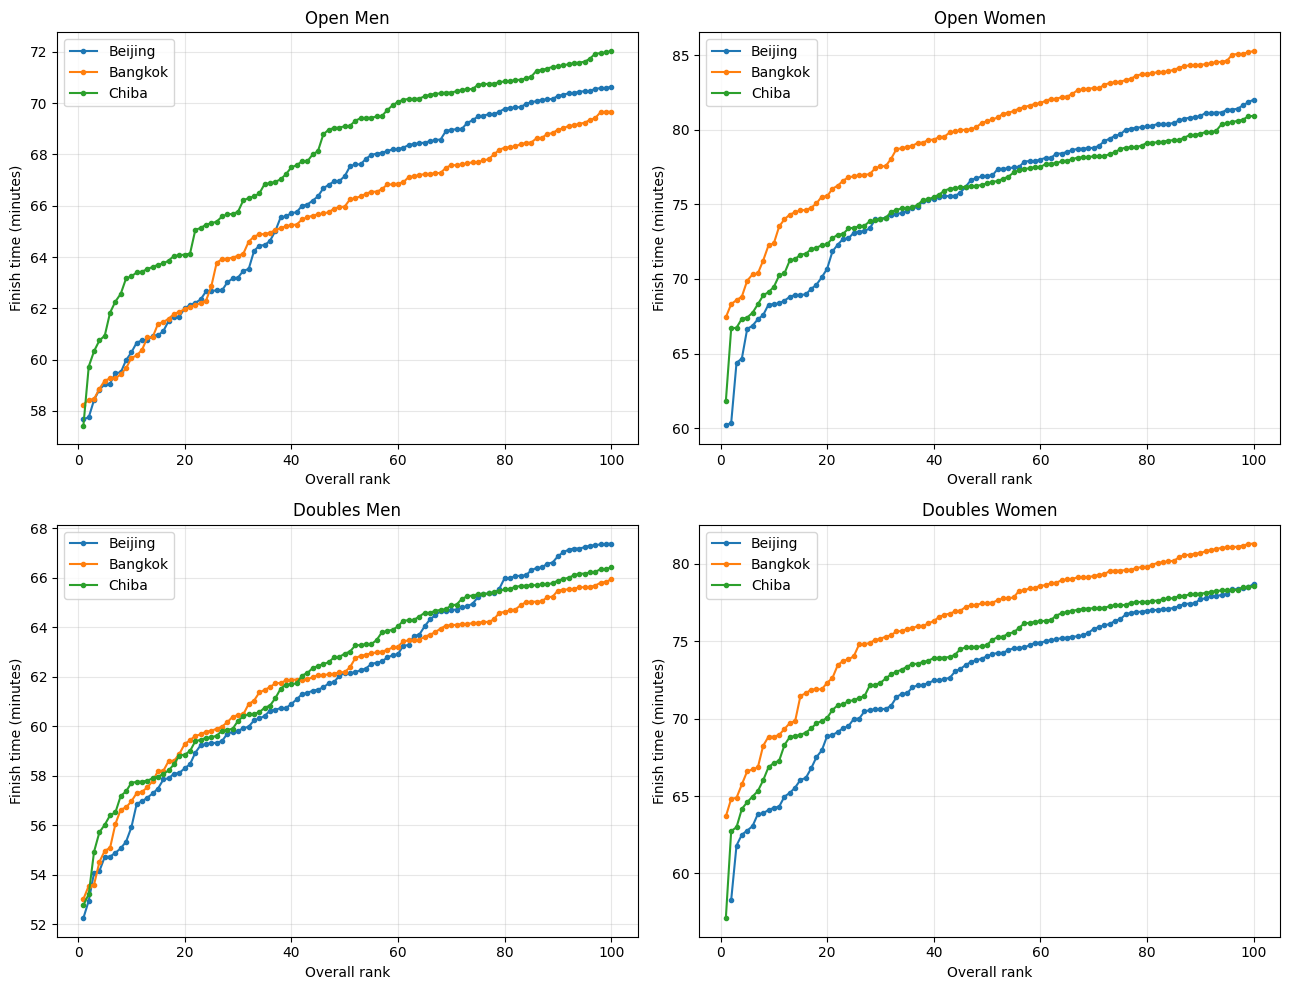

In [31]:
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h*60 + m + s/60

df['finish_min'] = df['finish_time'].apply(time_to_minutes)

cities = ['Beijing 2026', 'Bangkok 2026', 'Chiba 2026']  # add Chiba once data exists
categories = ['Open Men', 'Open Women', 'Doubles Men', 'Doubles Women']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, category in zip(axes, categories):
    for city in cities:
        sub = df[(df['race_name'] == city) & (df['race_category'] == category)].sort_values('overall_rank')
        if sub.empty:
            continue
        ax.plot(sub['overall_rank'], sub['finish_min'], marker='o', markersize=3, linewidth=1.5, label=city.replace(' 2026',''))
    ax.set_title(category)
    ax.set_xlabel('Overall rank')
    ax.set_ylabel('Finish time (minutes)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

Across both Open and Doubles categories, men's and women's races show clearly different competitive patterns between cities. In Men's races, Beijing and Chiba are fastest at the very top of the field, but Bangkok closes the gap and even overtakes both cities by the back half of the Top 100, suggesting Bangkok's men's field is less stacked at the elite end but deeper in the lower ranks. The women's races tell a different story: in both Open Women and Doubles Women, Bangkok is consistently slower than Beijing and Chiba across almost the entire Top 100. This points to a real disparity in women's field strength, with Bangkok's women finishing meaningfully slower at every rank than their counterparts in Beijing and Chiba. If this pattern persists, it suggests Bangkok may need to attract a stronger women's field to match the competitiveness already seen in its men's race, and could indicate room to grow participation or elite recruitment specifically on the women's side.

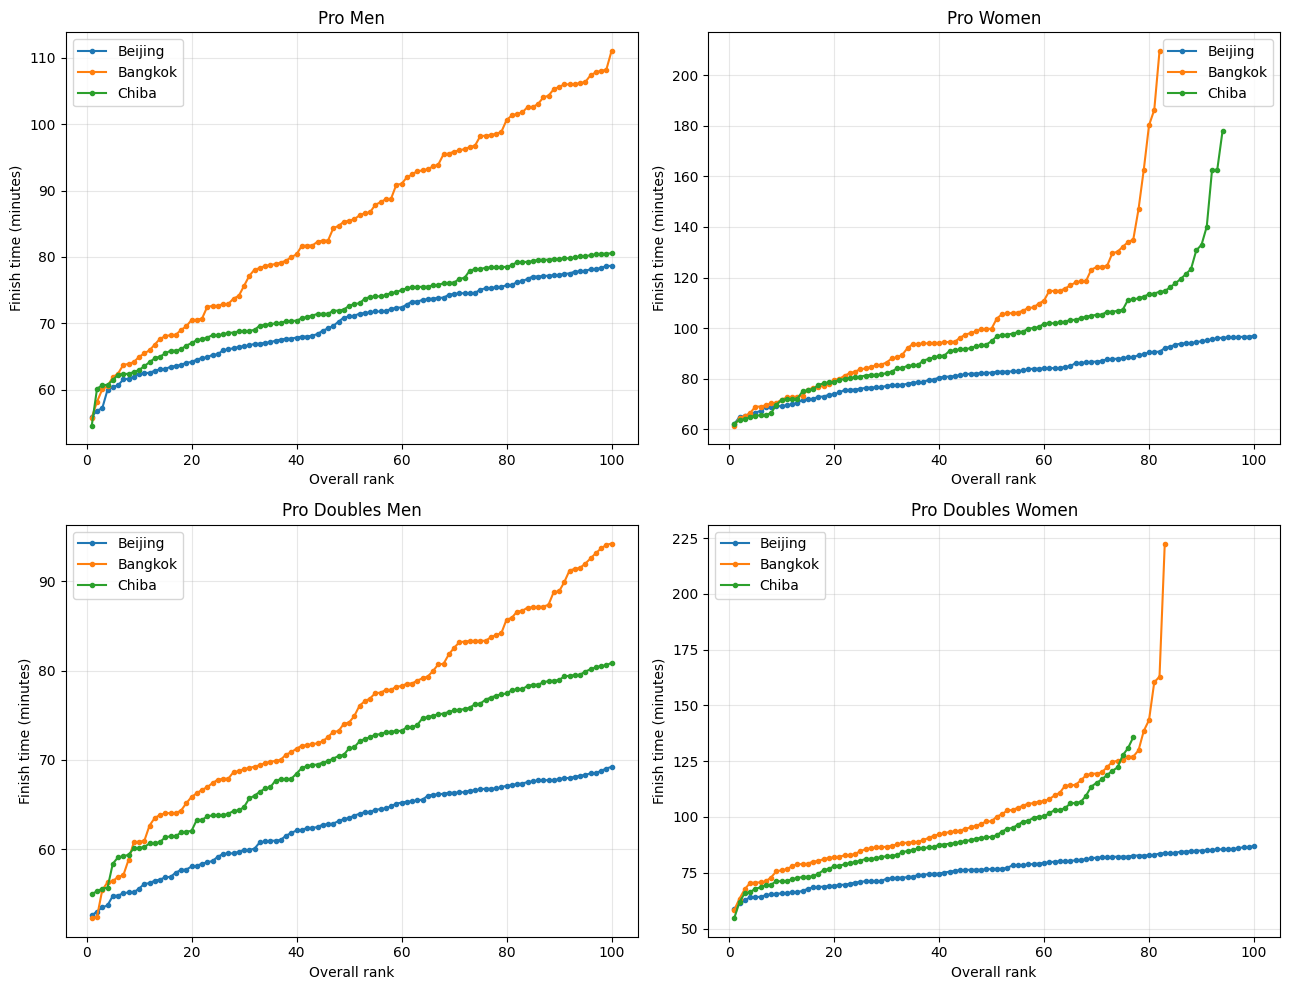

In [32]:
cities = ['Beijing 2026', 'Bangkok 2026', 'Chiba 2026']  # add Chiba once data exists
categories = ['Pro Men', 'Pro Women', 'Pro Doubles Men', 'Pro Doubles Women']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, category in zip(axes, categories):
    for city in cities:
        sub = df[(df['race_name'] == city) & (df['race_category'] == category)].sort_values('overall_rank')
        if sub.empty:
            continue
        ax.plot(sub['overall_rank'], sub['finish_min'], marker='o', markersize=3, linewidth=1.5, label=city.replace(' 2026',''))
    ax.set_title(category)
    ax.set_xlabel('Overall rank')
    ax.set_ylabel('Finish time (minutes)')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

The Pro categories show a clear difference in competitive depth across the three cities. Beijing consistently produces the most competitive field in Pro, followed by Chiba, then Bangkok — visible in Beijing's noticeably flatter, tighter curve across the Top 100 in all four Pro categories. This suggests Beijing draws a much deeper pool of elite-level athletes, where even the 100th-ranked finisher is still relatively close in pace to the leaders. Bangkok and Chiba, by contrast, show a sharp late blow-out in Pro Women and Pro Doubles Women — finish times spike dramatically past roughly rank 75-80, more than doubling from the leader's pace by rank 100 — indicating the elite women's fields in these cities thin out fast once you get past the top few dozen finishers. Beijing shows no such cliff in any Pro category, reinforcing that its Pro race is not just faster at the top but structurally deeper throughout. If this pattern holds, we might expect Beijing to remain the benchmark Pro-level HYROX event in the region, while Bangkok and Chiba may need to grow their elite women's field.

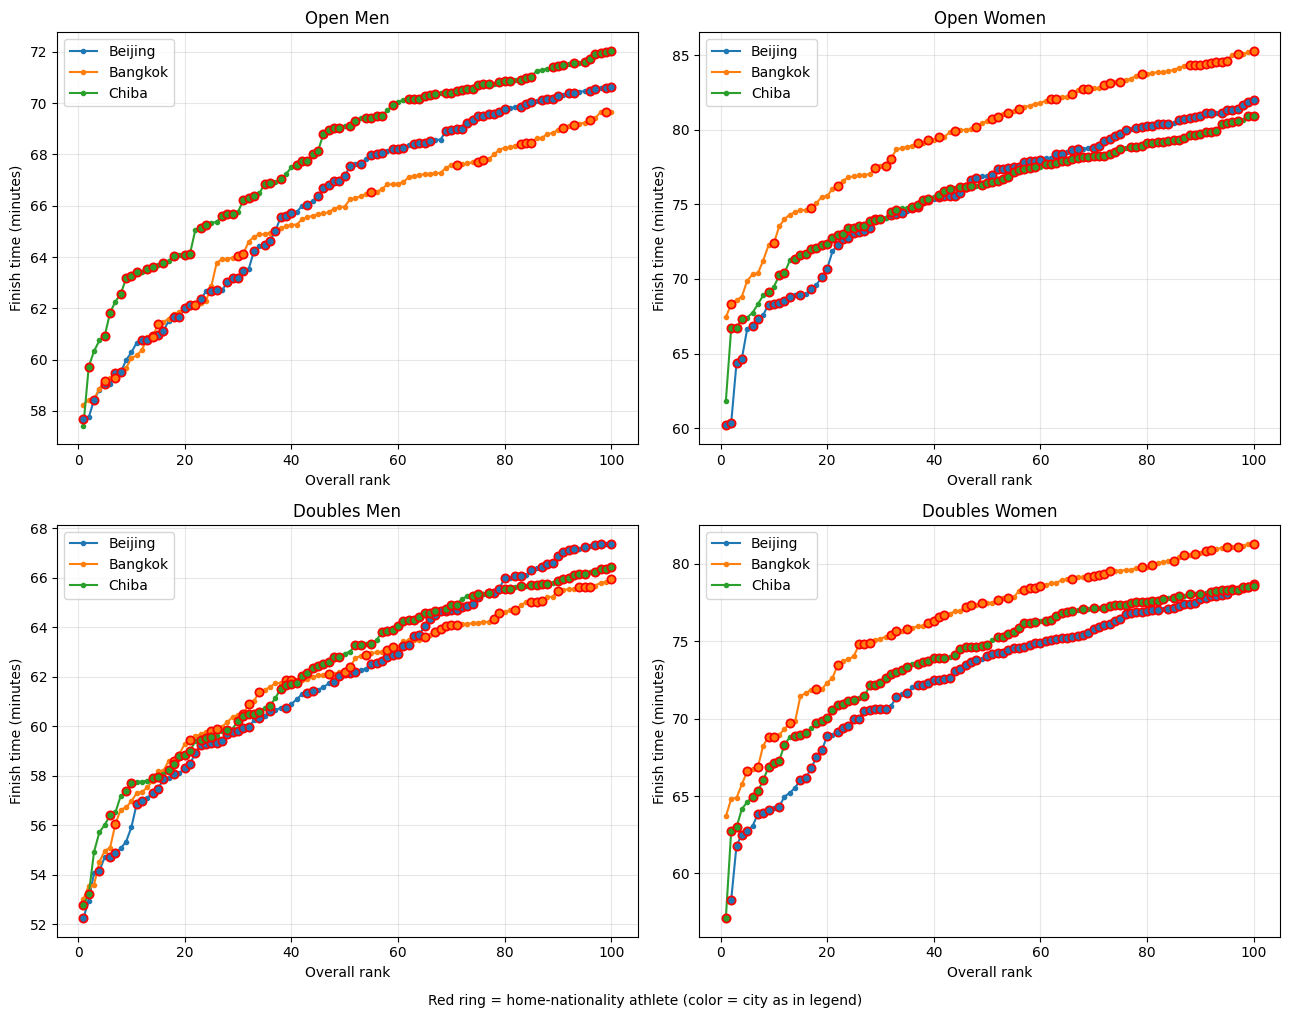

In [33]:
home_map = {
    'Beijing 2026': 'CHN',
    'Bangkok 2026': 'THA',
    'Chiba 2026': 'JPN',
}

cities = list(home_map.keys())
categories = ['Open Men', 'Open Women', 'Doubles Men', 'Doubles Women']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, category in zip(axes, categories):
    for city in cities:
        sub = df[(df['race_name'] == city) & (df['race_category'] == category)].sort_values('overall_rank')
        if sub.empty:
            continue

        line, = ax.plot(sub['overall_rank'], sub['finish_min'], marker='o', markersize=3,
                         linewidth=1.5, label=city.replace(' 2026', ''))
        city_color = line.get_color()  # grab this city's actual line color

        home_code = home_map[city]
        home_sub = sub[sub['nationality'] == home_code]
        # keep the city's own color as the fill, add a red ring to flag "home athlete"
        ax.scatter(home_sub['overall_rank'], home_sub['finish_min'],
                   facecolors=city_color, edgecolors='red', linewidths=1.3,
                   s=35, zorder=3, label='_nolegend_')

    ax.set_title(category)
    ax.set_xlabel('Overall rank')
    ax.set_ylabel('Finish time (minutes)')
    ax.grid(alpha=0.3)
    ax.legend()

fig.text(0.5, -0.01, 'Red ring = home-nationality athlete (color = city as in legend)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In Beijing and Chiba, home nation athlete cover almost every single point across all four categories, barely any gap. In Bangkok, you can spot visible gaps, most clearly in Open Men and Open Women's back half. Bangkok's home share is actually lowest in ranks 26–75 (only 8–12% Thai), and recovers somewhat at 76–100 (32%). Beijing, by contrast, is remarkably flat (64–76%) across every tier.

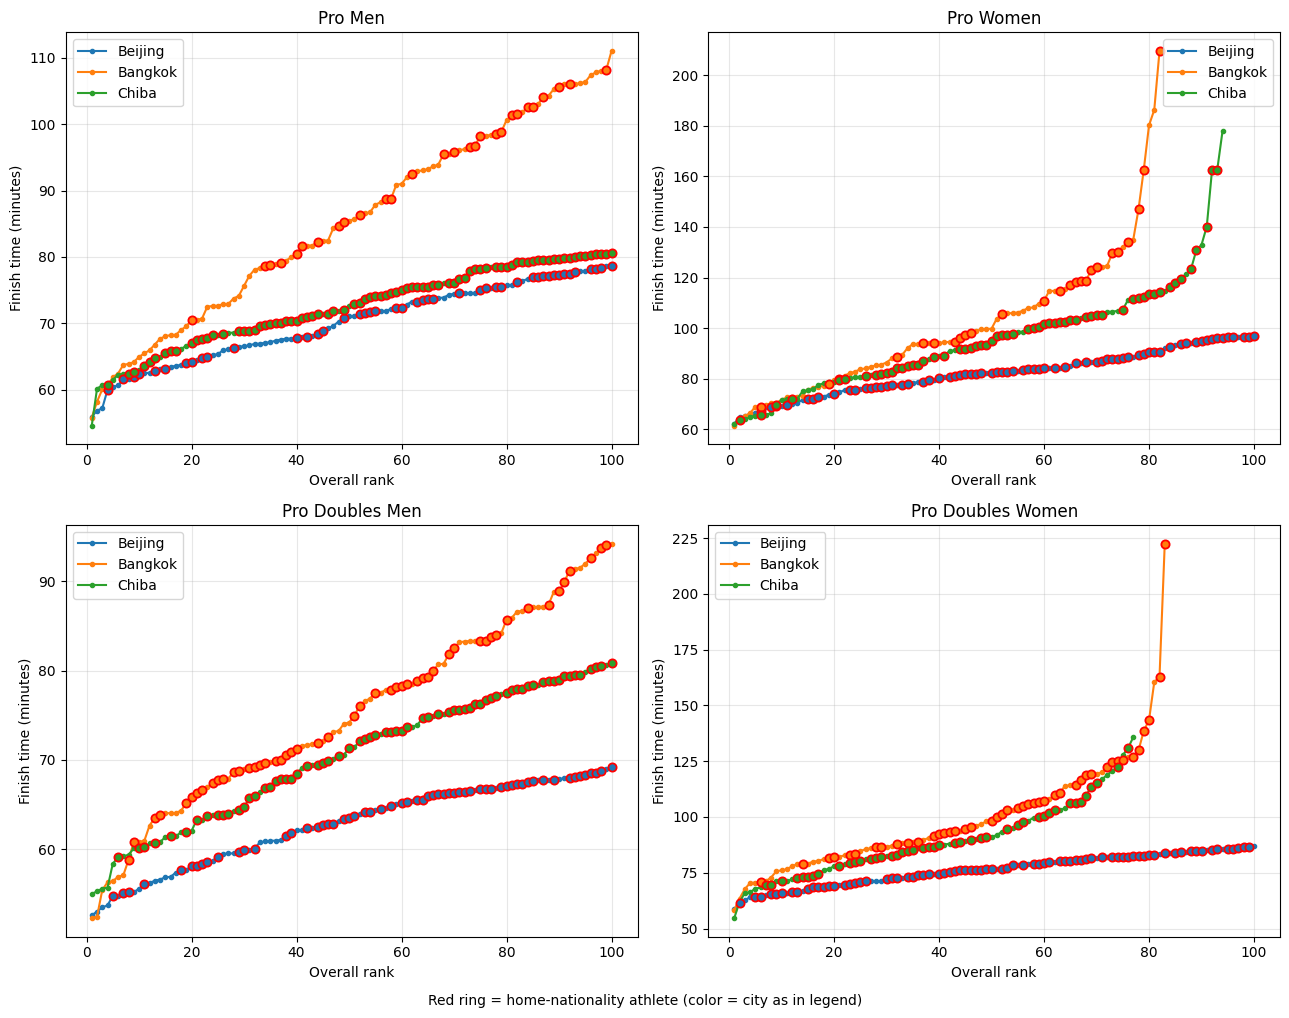

In [34]:
cities = list(home_map.keys())
categories = ['Pro Men', 'Pro Women', 'Pro Doubles Men', 'Pro Doubles Women']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, category in zip(axes, categories):
    for city in cities:
        sub = df[(df['race_name'] == city) & (df['race_category'] == category)].sort_values('overall_rank')
        if sub.empty:
            continue

        line, = ax.plot(sub['overall_rank'], sub['finish_min'], marker='o', markersize=3,
                         linewidth=1.5, label=city.replace(' 2026', ''))
        city_color = line.get_color()  # grab this city's actual line color

        home_code = home_map[city]
        home_sub = sub[sub['nationality'] == home_code]
        # keep the city's own color as the fill, add a red ring to flag "home athlete"
        ax.scatter(home_sub['overall_rank'], home_sub['finish_min'],
                   facecolors=city_color, edgecolors='red', linewidths=1.3,
                   s=35, zorder=3, label='_nolegend_')

    ax.set_title(category)
    ax.set_xlabel('Overall rank')
    ax.set_ylabel('Finish time (minutes)')
    ax.grid(alpha=0.3)
    ax.legend()

fig.text(0.5, -0.01, 'Red ring = home-nationality athlete (color = city as in legend)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In Pro Doubles Men, home athletes fill nearly the entire Top 100 across all three cities. Pro Men tells a different story: Chiba shows the strongest home-athlete presence, while Beijing and Bangkok both show noticeably more gaps, pointing to a larger contingent of traveling athletes in the men's Pro race outside Japan. In the women's Pro categories, both singles and doubles show a clear domination of Chinese athletes in Beijing — the ring is nearly continuous throughout the Top 100, indicating a deep and competitive local pool of Chinese women in the Pro tier. Bangkok and Chiba, by contrast, show a similar pattern of extreme late-race spikes at the top end of finish times, suggesting their Pro women's fields thin out sharply once past the leading pack, regardless of nationality.

## EP 2: More on foreign athletes and age categories differences

In [35]:
home_map = {
    'China': 'CHN',
    'Thailand': 'THA',
    'Japan': 'JPN',
}

df['home_code'] = df['race_country'].map(home_map)
df['is_home'] = df['nationality'] == df['home_code']

non_home = df[~df['is_home']]

# only these four categories
categories_of_interest = ['Open Men', 'Open Women', 'Doubles Men', 'Doubles Women']
non_home = non_home[non_home['race_category'].isin(categories_of_interest)]

# count non-home nationalities per race_category
counts = (
    non_home.groupby(['race_category', 'nationality'])
    .size()
    .reset_index(name='count')
)

# rank within each category (1 = most frequent)
counts['rank'] = counts.groupby('race_category')['count'].rank(method='first', ascending=False).astype(int)
counts = counts.sort_values(['race_category', 'rank'])

# show top 5 non-home nationalities per category
top_n = 5
top_non_home = counts[counts['rank'] <= top_n]

print(top_non_home.to_string(index=False))

race_category nationality  count  rank
  Doubles Men         KOR     41     1
  Doubles Men         HKG     12     2
  Doubles Men         SIN      6     3
  Doubles Men         AUS      4     4
  Doubles Men         PHI      3     5
Doubles Women         MAS     12     1
Doubles Women         HKG      8     2
Doubles Women         KOR      8     3
Doubles Women         PHI      6     4
Doubles Women         INA      5     5
     Open Men         KOR     37     1
     Open Men         HKG     11     2
     Open Men         GBR     10     3
     Open Men         AUS      9     4
     Open Men         USA      8     5
   Open Women         KOR     15     1
   Open Women         SIN     10     2
   Open Women         HKG      6     3
   Open Women         MAS      6     4
   Open Women         PHI      6     5
